In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss

# 1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция. Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с параметрами test_size = 0.8 и random_state = 241.

In [7]:
data = pd.read_csv('gbm-data.csv')
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=241
)

# 2. Обучите GradientBoostingClassifier с параметрами n_estimators=250, verbose=True, random_state=241 и для каждого значения learning_rate из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:
• Используйте метод staged_decision_function для предсказа-
ния качества на обучающей и тестовой выборке на каждой
итерации.

• Преобразуйте полученное предсказание по формуле 1
1+e−y_pred ,
где y_pred - предсказанное значение.

• Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.


Обучение с learning_rate = 1

Обучение с learning_rate = 0.5

Обучение с learning_rate = 0.3

Обучение с learning_rate = 0.2

Обучение с learning_rate = 0.1


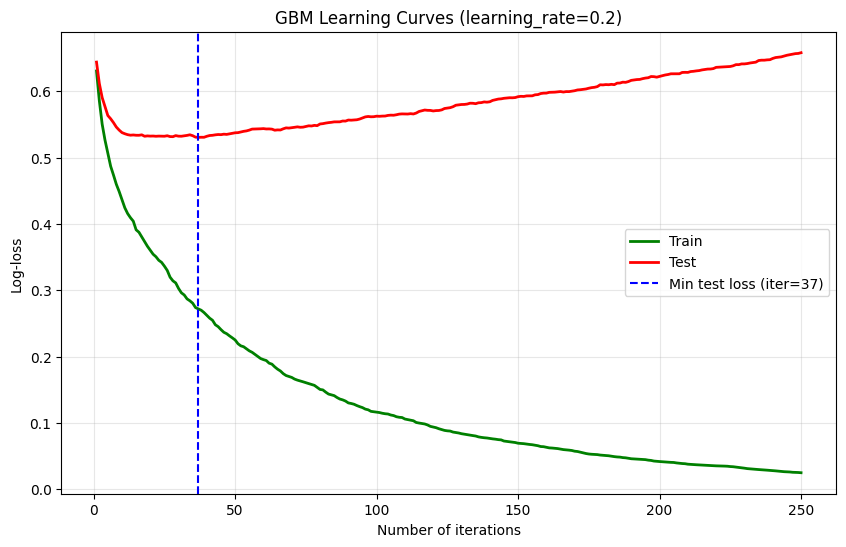

In [9]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
best_for_lr_02 = {}  # словарь для хранения результата при lr=0.2

for lr in learning_rates:
    print(f"\nОбучение с learning_rate = {lr}")

    gbm = GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=lr,
        random_state=241,
        verbose=False
    )
    gbm.fit(X_train, y_train)

    # Считаем log-loss на тесте после каждого дерева
    test_losses = []
    for pred in gbm.staged_decision_function(X_test):
        proba = 1.0 / (1.0 + np.exp(-pred))
        test_losses.append(log_loss(y_test, proba))

    # Для lr=0.2 запоминаем результат
    if lr == 0.2:
        best_for_lr_02['min_loss'] = min(test_losses)
        best_for_lr_02['iteration'] = np.argmin(test_losses) + 1

# Строим график для learning_rate = 0.2
gbm_02 = GradientBoostingClassifier(
    n_estimators=250, learning_rate=0.2, random_state=241, verbose=False
)
gbm_02.fit(X_train, y_train)

train_losses = []
for pred in gbm_02.staged_decision_function(X_train):
    proba = 1.0 / (1.0 + np.exp(-pred))
    train_losses.append(log_loss(y_train, proba))

test_losses = []
for pred in gbm_02.staged_decision_function(X_test):
    proba = 1.0 / (1.0 + np.exp(-pred))
    test_losses.append(log_loss(y_test, proba))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 251), train_losses, 'g', linewidth=2, label='Train')
plt.plot(range(1, 251), test_losses, 'r', linewidth=2, label='Test')
plt.axvline(x=best_for_lr_02['iteration'], color='b', linestyle='--',
            label=f'Min test loss (iter={best_for_lr_02["iteration"]})')
plt.xlabel('Number of iterations')
plt.ylabel('Log-loss')
plt.title(f'GBM Learning Curves (learning_rate=0.2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)? В ответе укажите одно из слов overfitting либо underfitting

In [ ]:
print("Ответ: overfitting")

# 4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

In [10]:
print(f"Минимальный log-loss: {best_for_lr_02['min_loss']:.2f}")
print(f"Номер итерации: {best_for_lr_02['iteration']}")

Минимальный log-loss: 0.53
Номер итерации: 37


# 5. На этих же данных обучите RandomForestClassifier с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию. Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции predict_proba. В данном случае брать сигмоиду от оценки вероятности класса не нужно)

In [12]:
rf = RandomForestClassifier(
    n_estimators=best_for_lr_02['iteration'],
    random_state=241
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_loss = log_loss(y_test, rf_proba)

print(f"Log-loss случайного леса: {rf_loss:.2f}")

Log-loss случайного леса: 0.54
